# Tarea 2 Data Analysis y Machine Learning
## Joaquín Aravena 2021454110

### Librerias a usar

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
import linearmodels.panel as lmp
import seaborn as sns
from linearmodels.iv import IV2SLS
import missingno as msno
import warnings


warnings.filterwarnings("ignore")

%matplotlib inline

### Parte 1: Lectura y limpieza de datos

In [43]:
df = pd.read_csv("panel_eps.csv")
df = df.sort_values(by="folio_n20")

Se excluyen todas las muestras que no hayan establecido su expectativa de vida (Que corresponden en su mayoria a la ronda 4) ni años de educacion

Se rellena la información faltante de la gente sin hijos

Se eliminan las columnas con todos los datos faltantes



In [44]:
df.drop(columns=["fondoa","fondob","fondoc","fondod","fondoe"],inplace=True)
df = df[(~df["expectancy"].isna()) & ~df["edu"].isna() & (df["expectancy"] < 110)]
df.reset_index(drop=True, inplace=True)
df.loc[(df["kids"] == 0) & (df["children"].isna()), "children"] = 0 #Si no tiene hijos y en childresn tiene NaN, rellenar con 0

df

,folio_n20,year,time,edad,hombre,edu,region,status,kids,children,...,publicemp,sistema,cotizando,assets,exp_sist,expectancy,illness,cronica,nocronica,mental
0,124560204870,4,2,49,0.0,7.0,5.0,3.0,1,1.0,...,NaN,NaN,0.0,0.00,0,58.0,1.0,0.0,1.0,0.0
1,124560204870,6,3,51,0.0,4.0,5.0,3.0,1,1.0,...,NaN,0.0,0.0,0.00,0,55.0,0.0,0.0,0.0,0.0
2,124560204870,9,4,54,0.0,5.0,5.0,3.0,1,1.0,...,NaN,1.0,0.0,0.00,0,70.0,1.0,0.0,0.0,1.0
3,124560204870,12,5,57,0.0,4.0,NaN,5.0,0,0.0,...,0.0,0.0,0.0,NaN,0,70.0,1.0,0.0,0.0,0.0
4,124560205935,2,1,1982,0.0,15.0,13.0,3.0,1,4.0,...,NaN,1.0,0.0,989038.06,19,75.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64978,128133653188,12,5,1992,0.0,16.0,NaN,3.0,0,0.0,...,NaN,1.0,0.0,NaN,7,80.0,0.0,0.0,0.0,0.0
64979,128133692735,12,5,1992,0.0,12.0,NaN,2.0,0,0.0,...,0.0,1.0,1.0,NaN,7,80.0,1.0,0.0,0.0,0.0
64980,128133702320,12,5,1992,0.0,15.0,NaN,5.0,0,0.0,...,NaN,1.0,1.0,NaN,7,75.0,0.0,0.0,0.0,0.0
64981,128133728022,12,5,1992,0.0,8.0,NaN,2.0,0,0.0,...,1.0,1.0,1.0,NaN,6,70.0,1.0,0.0,0.0,0.0


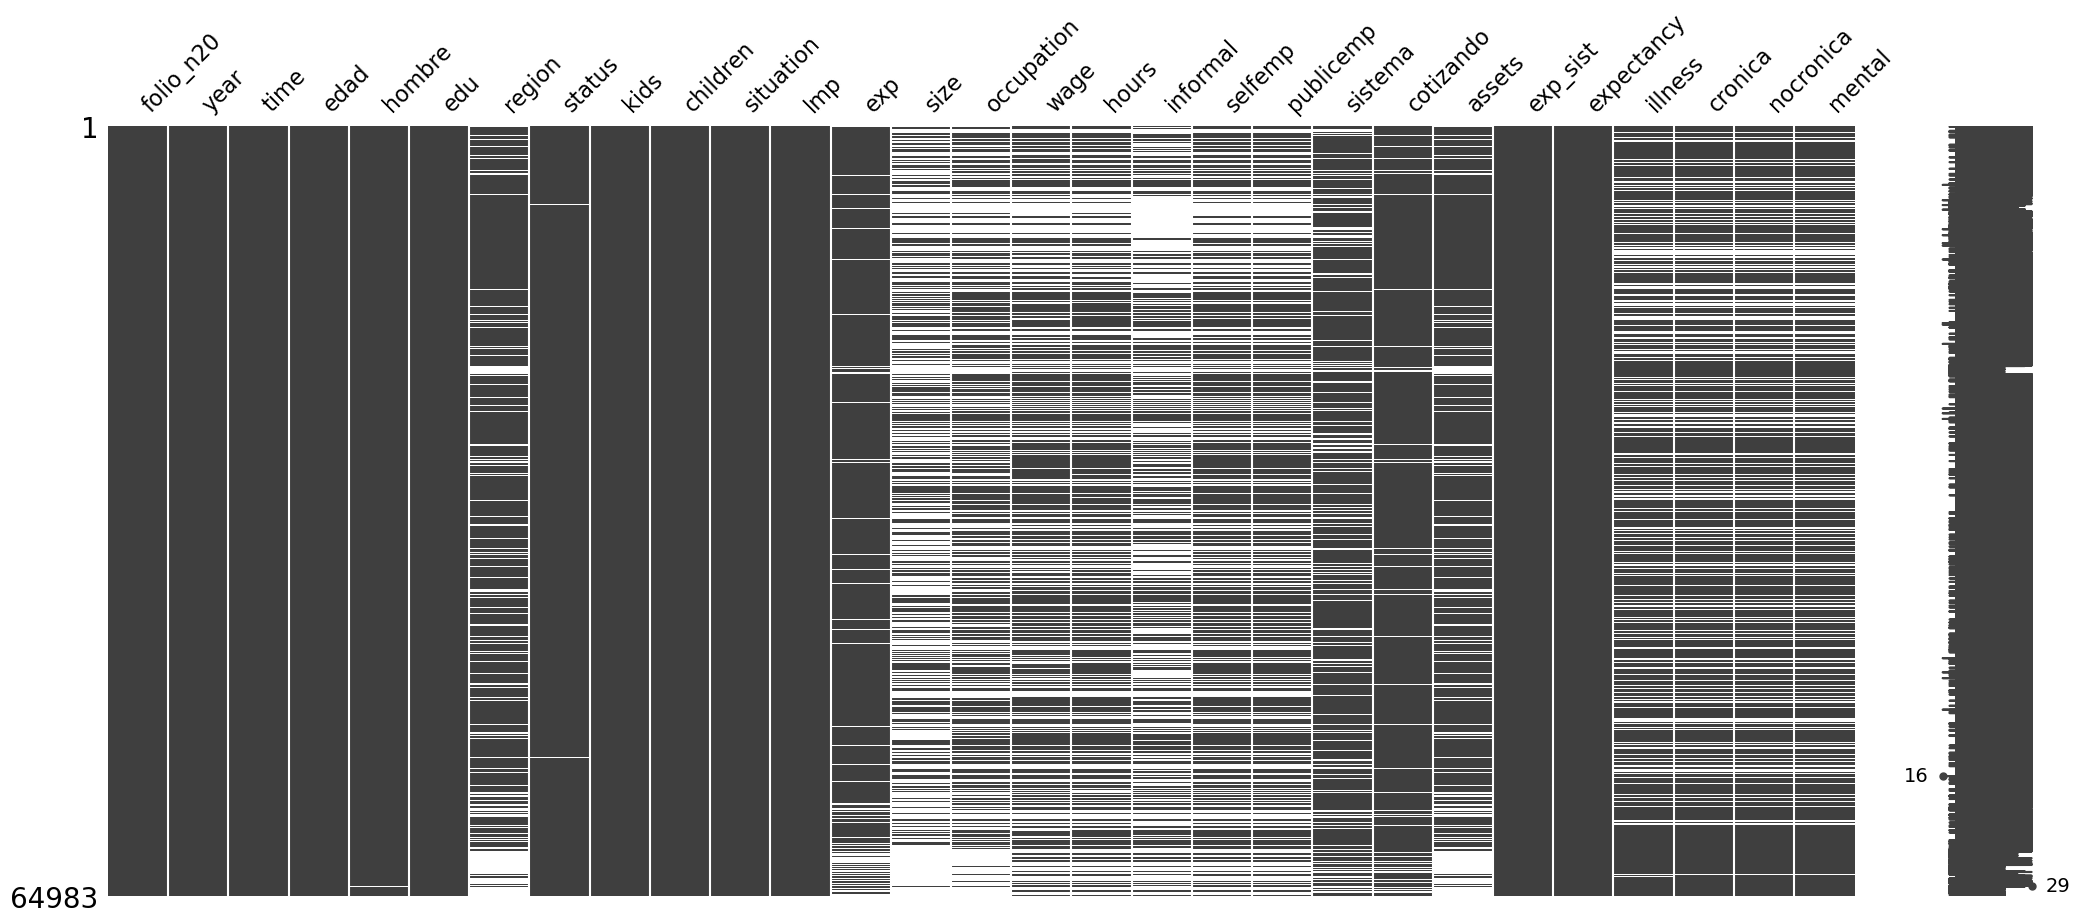

In [45]:
msno.matrix(df)
plt.show()

Se aprecia en el gráfico de datos faltantes como las variables relacionadas al trabajo tienen muchos vacios. La razón de esto es que, la gente inactiva y sin empleo no contestaron estos campos, por lo que se procede a rellenarlos con 0

In [46]:
df[df["situation"] == 2][["size", "occupation", "wage", "hours", "informal", "selfemp", "publicemp"]]
cols = ["size", "occupation", "wage", "hours", "informal", "selfemp", "publicemp"]
df.loc[df["situation"].isin([2, 4]), cols] = df.loc[df["situation"].isin([2, 4]), cols].fillna(0)

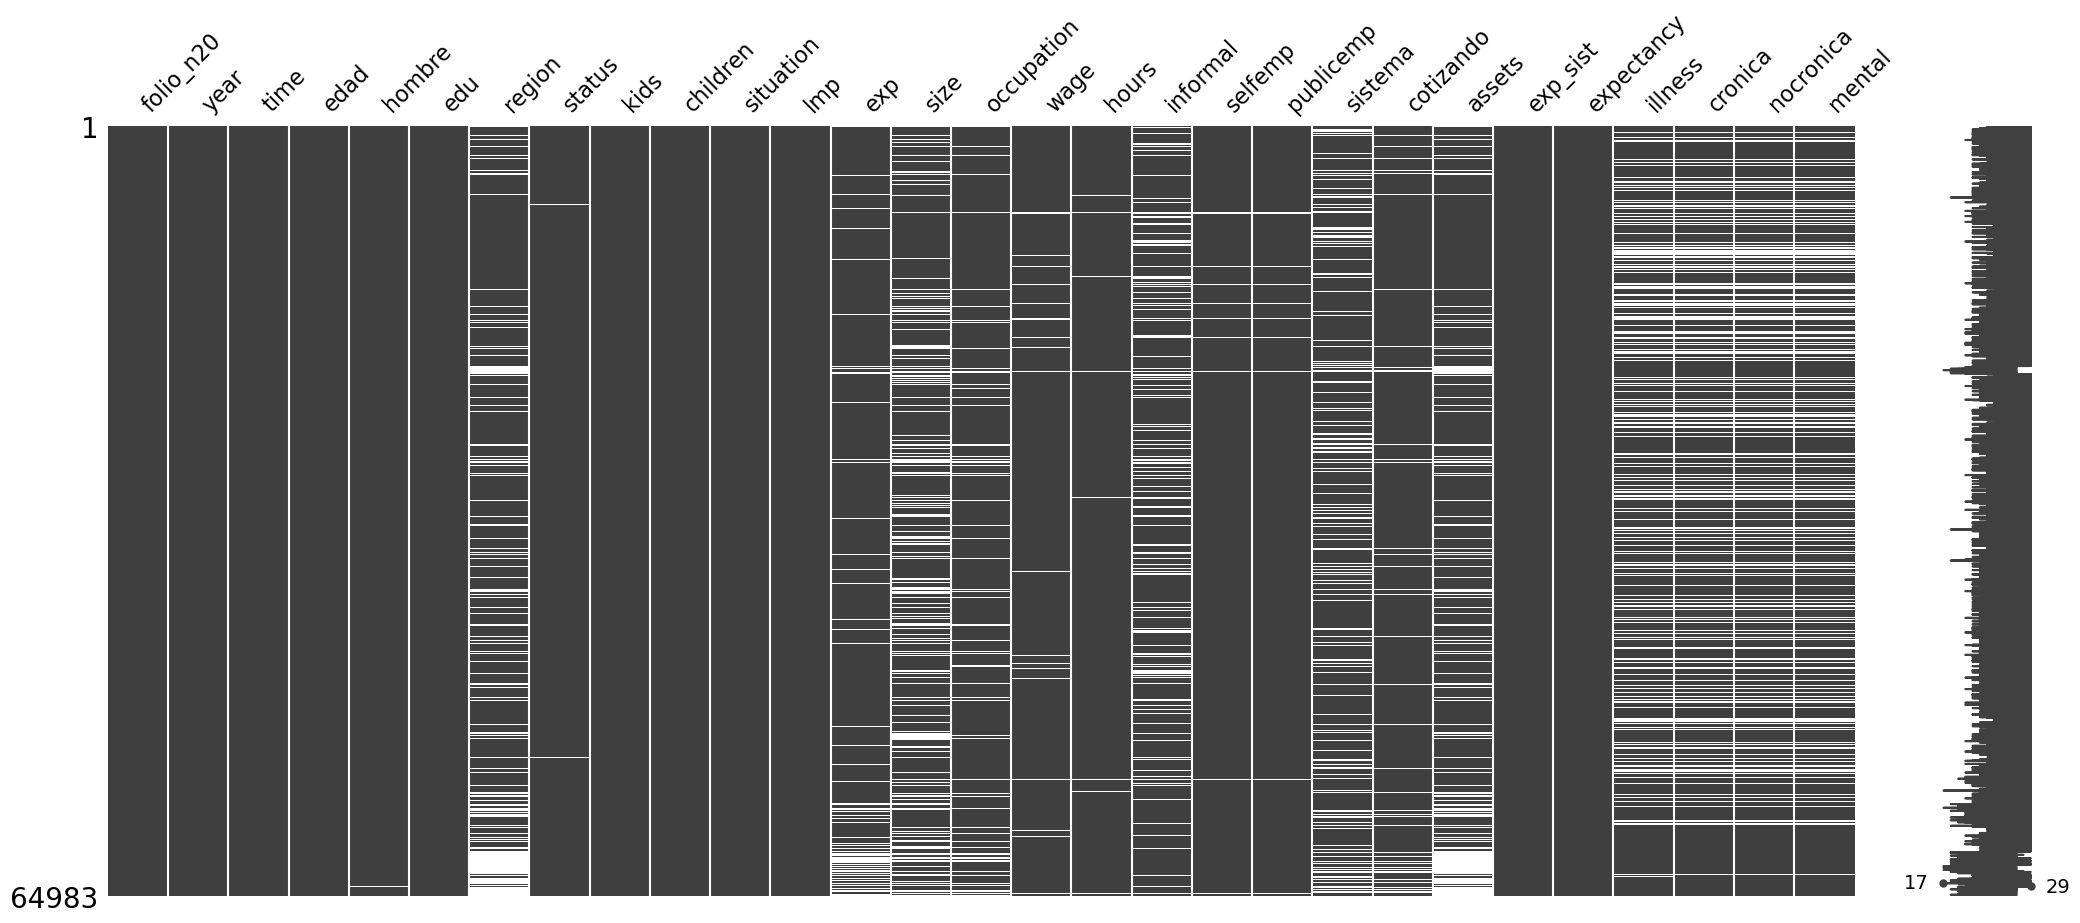

In [47]:
msno.matrix(df)
plt.show()

La información faltante en la columna de enfermedades corresponde a la ronda 1, donde nadie contestó dicho campo.

Se eliminan las columnas que no se usarán en el analisis

In [48]:
df.drop(columns=["region","size","informal","hours","selfemp"],inplace=True)
df

,folio_n20,year,time,edad,hombre,edu,status,kids,children,situation,...,publicemp,sistema,cotizando,assets,exp_sist,expectancy,illness,cronica,nocronica,mental
0,124560204870,4,2,49,0.0,7.0,3.0,1,1.0,4,...,0.0,NaN,0.0,0.00,0,58.0,1.0,0.0,1.0,0.0
1,124560204870,6,3,51,0.0,4.0,3.0,1,1.0,4,...,0.0,0.0,0.0,0.00,0,55.0,0.0,0.0,0.0,0.0
2,124560204870,9,4,54,0.0,5.0,3.0,1,1.0,4,...,0.0,1.0,0.0,0.00,0,70.0,1.0,0.0,0.0,1.0
3,124560204870,12,5,57,0.0,4.0,5.0,0,0.0,3,...,0.0,0.0,0.0,NaN,0,70.0,1.0,0.0,0.0,0.0
4,124560205935,2,1,1982,0.0,15.0,3.0,1,4.0,4,...,0.0,1.0,0.0,989038.06,19,75.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64978,128133653188,12,5,1992,0.0,16.0,3.0,0,0.0,4,...,0.0,1.0,0.0,NaN,7,80.0,0.0,0.0,0.0,0.0
64979,128133692735,12,5,1992,0.0,12.0,2.0,0,0.0,3,...,0.0,1.0,1.0,NaN,7,80.0,1.0,0.0,0.0,0.0
64980,128133702320,12,5,1992,0.0,15.0,5.0,0,0.0,4,...,0.0,1.0,1.0,NaN,7,75.0,0.0,0.0,0.0,0.0
64981,128133728022,12,5,1992,0.0,8.0,2.0,0,0.0,3,...,1.0,1.0,1.0,NaN,6,70.0,1.0,0.0,0.0,0.0


Se aprecia como en la ronda 5 nadie respondió por sus ahorros previsionales

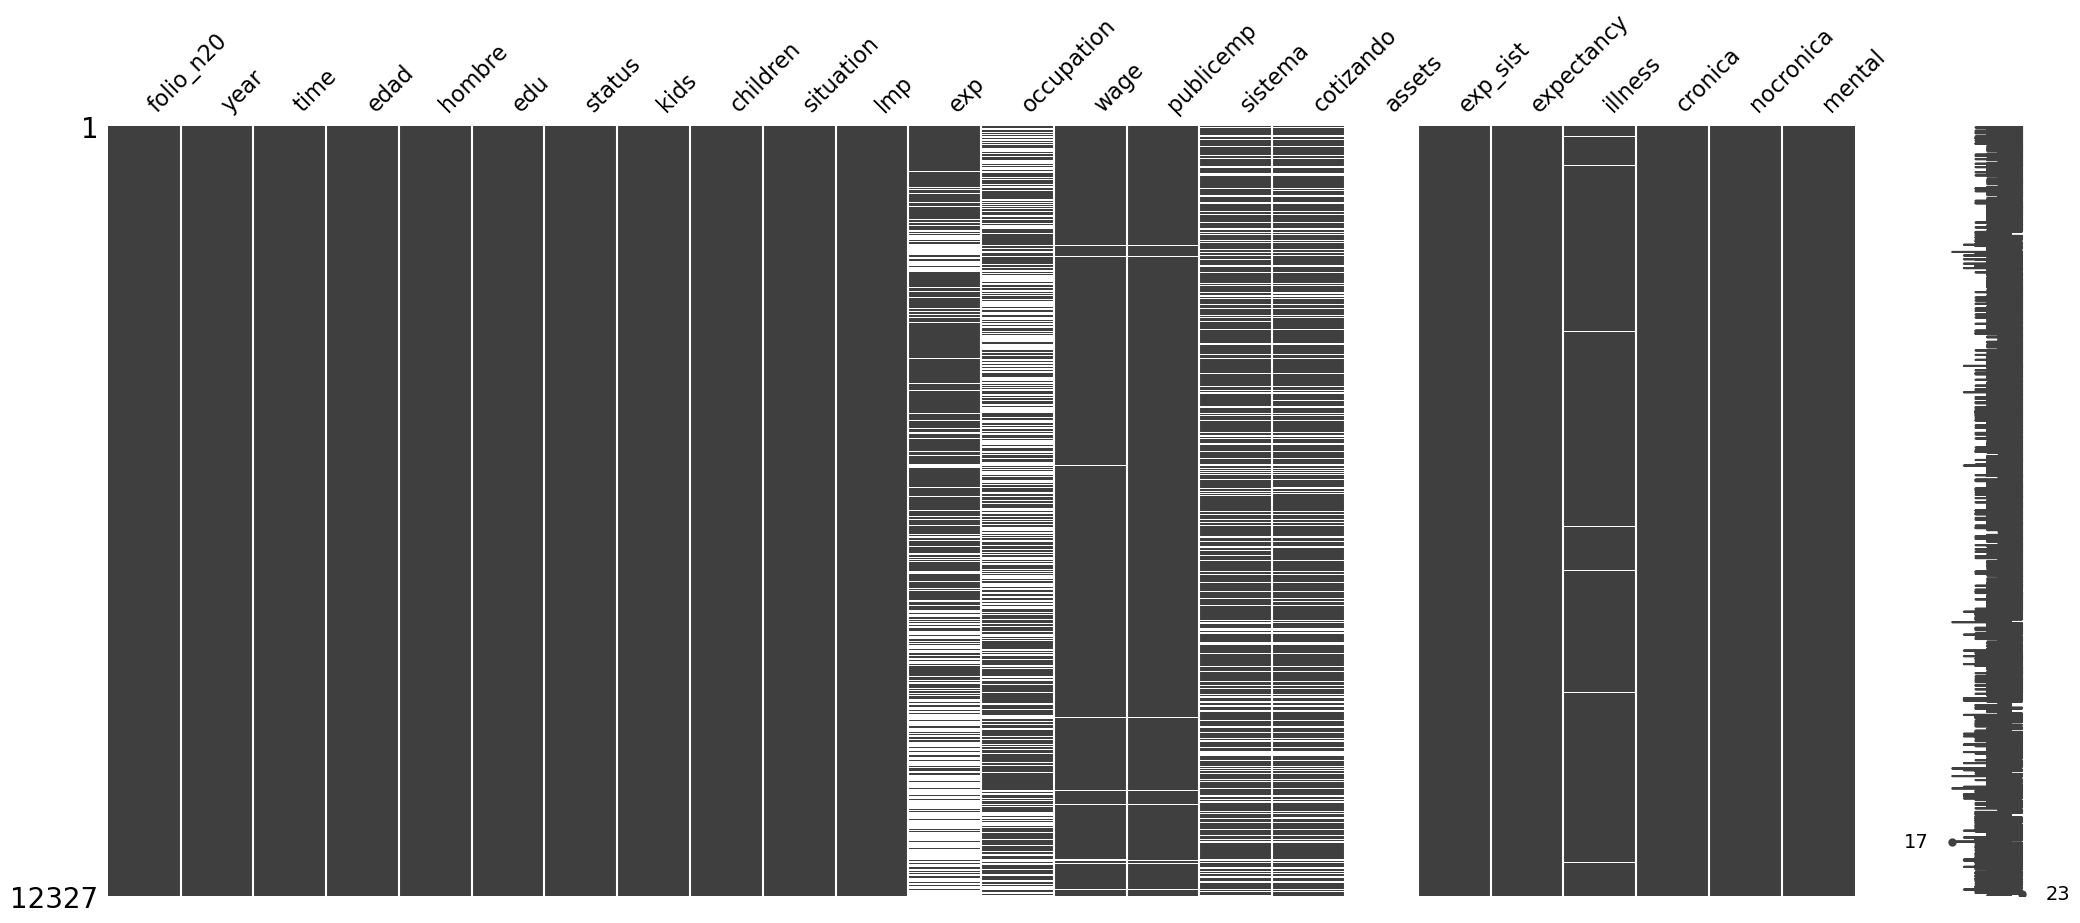

In [49]:
msno.matrix(
df[(df["time"] == 5) & df.isna().any(axis=1)]
)
plt.show()

Se realizará un promedio entre la ronda 3 y 6 para aproximar este valor

In [50]:
# Imputar assets en time == 5 con el último valor conocido en time < 5
folios = df[(df["time"] == 5) & (df["assets"].isna())]["folio_n20"].unique()
ultimos_assets = (
    df[(df["folio_n20"].isin(folios)) & (df["time"] < 5)]
    .sort_values(["folio_n20", "time"])
    .groupby("folio_n20")["assets"]
    .last()
)

df.loc[(df["time"] == 5) & (df["folio_n20"].isin(ultimos_assets.index)) & (df["assets"].isna()), "assets"] = \
    df.loc[(df["time"] == 5) & (df["folio_n20"].isin(ultimos_assets.index)) & (df["assets"].isna()), "folio_n20"] \
    .map(ultimos_assets)

df.loc[(df["cotizando"] == 0) & (df["assets"].isna()), "assets"] = 0 #Inputar con 0 gente que no cotiza


Se ajusta el sueldo a una escala logaritmica para una mejor interpretación de su coeficiente mas adelante.

In [51]:
df["wage"] = np.log(df["wage"] + 0.1)
df["assets"] = np.log(df["assets"] + 0.1)

Se limpian los datos faltantes y crea e l nuevo indice

In [52]:
df = df.dropna()
df = df.set_index(["folio_n20","year"])
df

time  edad  hombre   edu  status  kids  children  \
folio_n20    year                                                     
124560205935 4        2  1984     0.0  15.0     3.0     1       3.0   
124560210408 12       5  1992     0.0   3.0     4.0     0       0.0   
             4        2  1984     0.0   4.0     1.0     0       0.0   
             6        3  1986     0.0   3.0     1.0     0       0.0   
124560216585 4        2  1984     0.0   7.0     1.0     1       1.0   
...                 ...   ...     ...   ...     ...   ...       ...   
128131545766 12       5  1992     0.0   8.0     5.0     0       0.0   
128131933639 12       5  1992     0.0  15.0     5.0     0       0.0   
128132490563 12       5  1992     0.0   8.0     5.0     0       0.0   
128132865727 12       5  1992     0.0   4.0     1.0     0       0.0   
128133265173 12       5  1992     0.0   8.0     5.0     0       0.0   

                   situation  lmp   exp  ...  publicemp  sistema  cotizando  \
folio_n20    year                        ...                                  
124560205935 4             4    0   6.0  ...        0.0      1.0        0.0   
124560210408 12            4    0  29.0  ...        0.0      1.0        1.0   
             4             3    2  23.0  ...        0.0      1.0        1.0   
             6             3    2  26.0  ...        0.0      1.0        1.0   
124560216585 4             3    2  10.0  ...        0.0      1.0        1.0   
...                      ...  ...   ...  ...        ...      ...        ...   
128131545766 12            4    0   0.0  ...        0.0      1.0        0.0   
128131933639 12            4    0   0.0  ...        0.0      1.0        0.0   
128132490563 12            4    0   0.0  ...        0.0      1.0        0.0   
128132865727 12            4    0   0.0  ...        0.0      1.0        0.0   
128133265173 12            2    0   0.0  ...        0.0      1.0        0.0   

                      assets  exp_sist  expectancy  illness  cronica  \
folio_n20    year                                                      
124560205935 4     -2.302585        21        70.0      1.0      1.0   
124560210408 12    11.947861        14        72.0      1.0      0.0   
             4     -2.302585         6        70.0      0.0      0.0   
             6     11.947861         8        75.0      1.0      1.0   
124560216585 4     12.666009         3        80.0      1.0      0.0   
...                      ...       ...         ...      ...      ...   
128131545766 12    -2.302585         8        80.0      0.0      0.0   
128131933639 12    -2.302585         9        70.0      1.0      0.0   
128132490563 12    -2.302585        10        60.0      0.0      0.0   
128132865727 12    -2.302585        12        90.0      0.0      0.0   
128133265173 12    -2.302585         7        90.0      0.0      0.0   

                   nocronica  mental  
folio_n20    year                     
124560205935 4           1.0     0.0  
124560210408 12          0.0     0.0  
             4           0.0     0.0  
             6           0.0     0.0  
124560216585 4           1.0     0.0  
...                      ...     ...  
128131545766 12          0.0     0.0  
128131933639 12          0.0     0.0  
128132490563 12          0.0     0.0  
128132865727 12          0.0     0.0  
128133265173 12          0.0     0.0  

[30159 rows x 22 columns]

Se calculan las columnas dummy

In [53]:
df = pd.get_dummies(df, columns=["status", "situation", "lmp","occupation", "time"], drop_first=True)
df = df.astype(int)
df

edad  hombre  edu  kids  children  exp  wage  publicemp  \
folio_n20    year                                                            
124560205935 4     1984       0   15     1         3    6    -2          0   
124560210408 12    1992       0    3     0         0   29    -2          0   
             4     1984       0    4     0         0   23    11          0   
             6     1986       0    3     0         0   26    11          0   
124560216585 4     1984       0    7     1         1   10    12          0   
...                 ...     ...  ...   ...       ...  ...   ...        ...   
128131545766 12    1992       0    8     0         0    0    -2          0   
128131933639 12    1992       0   15     0         0    0    -2          0   
128132490563 12    1992       0    8     0         0    0    -2          0   
128132865727 12    1992       0    4     0         0    0    -2          0   
128133265173 12    1992       0    8     0         0    0    -2          0   

                   sistema  cotizando  ...  occupation_4.0  occupation_5.0  \
folio_n20    year                      ...                                   
124560205935 4           1          0  ...               0               0   
124560210408 12          1          1  ...               0               0   
             4           1          1  ...               0               0   
             6           1          1  ...               0               0   
124560216585 4           1          1  ...               0               0   
...                    ...        ...  ...             ...             ...   
128131545766 12          1          0  ...               0               0   
128131933639 12          1          0  ...               0               0   
128132490563 12          1          0  ...               0               0   
128132865727 12          1          0  ...               0               0   
128133265173 12          1          0  ...               0               0   

                   occupation_6.0  occupation_7.0  occupation_8.0  \
folio_n20    year                                                   
124560205935 4                  0               0               0   
124560210408 12                 0               0               0   
             4                  0               0               0   
             6                  0               0               0   
124560216585 4                  0               0               0   
...                           ...             ...             ...   
128131545766 12                 0               0               0   
128131933639 12                 0               0               0   
128132490563 12                 0               0               0   
128132865727 12                 0               0               0   
128133265173 12                 0               0               0   

                   occupation_9.0  occupation_10.0  time_3  time_4  time_5  
folio_n20    year                                                           
124560205935 4                  0                0       0       0       0  
124560210408 12                 0                0       0       0       1  
             4                  1                0       0       0       0  
             6                  1                0       1       0       0  
124560216585 4                  1                0       0       0       0  
...                           ...              ...     ...     ...     ...  
128131545766 12                 0                0       0       0       1  
128131933639 12                 0                0       0       0       1  
128132490563 12                 0                0       0       0       1  
128132865727 12                 0                0       0       0       1  
128133265173 12                 0                0       0       0       1  

[30159 rows x 38 columns]

Finalmente, nos quedamos con 4 rondas

In [54]:
# Contar cuántas veces aparece cada folio_n20 (cuántos periodos respondió)
conteo_periodos = df.groupby("folio_n20").size()

# Contar cuántas personas hay por cada cantidad de periodos
resumen = conteo_periodos.value_counts().sort_index()

# Mostrar el resumen
print(resumen)

1    5162
2    5287
3    3809
4     749
Name: count, dtype: int64


### Parte 2
#### Ejecute un modelo Pooled OLS para estimar la relacion entre los anios de educacion y la expectativa de vida. Seleccione las variables independientes a incluir en el modelo final e interprete su significado.

In [55]:
#Minimo cuadrado agrupado
y=df['expectancy']
X=df[[
      'edu',
      'children',
      'exp',
      "wage",
      'cotizando',
      "publicemp",
      "sistema",
      'assets',
      "exp_sist",
      "cronica",
      "nocronica",
      "mental",
      'status_2.0',
      'status_3.0',
      "status_4.0",
      "status_5.0",
      "situation_3",
      "situation_4",
      "occupation_1.0",
      "time_3",
      "time_4",
      "time_5"      
      ]]
X=sm.add_constant(X)

model = lmp.PanelOLS(y, X)
mco = model.fit()
print(mco)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0539
Estimator:                   PanelOLS   R-squared (Between):              0.0806
No. Observations:               30159   R-squared (Within):               0.0055
Date:                Tue, May 20 2025   R-squared (Overall):              0.0539
Time:                        20:53:55   Log-likelihood                 -1.12e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      78.093
Entities:                       15007   P-value                           0.0000
Avg Obs:                       2.0097   Distribution:                F(22,30136)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             78.093
                            

In [63]:
12*0.6

7.199999999999999

Podemos ver que el modelo es bastante malo, al tener un R2 de 5.5%.  

Se busca estudiar la relación entre la educación y la expectativa de vida. El coeficiente que acompaña a esta variable resultó positivo, indicando que, cada año de educación aumenta la expectativa de vida poco más de 2 semanas. Esto no es un impacto tan alto considerando que los años de educación van de 1 a 16, teniendo como máximo impacto posible aprox 3 años. 

Otros resultados interesantes son:

Por cada hijo, la expectativa de vida autopercibida de las personas disminuye en 0.55 (Aproximadamente 7 meses). Esto no sigue la lógica, ya que segun diversos estudios la expectativa de vida de las personas aumenta con los hijos. Esto podria tener relación a una mala muestra o falta de alguna variable relevante.

Un aumento en el 1% del salario de una persona, aumenta su expectativa de vida en 3 meses. Esto va de acuerdo a lo esperado al ayudar al acceso a mejor salud, medicamentos y en general mejorar el estandar de vida.

Como resultado interesante, se tiene que un empleado publico tendrá expectativa de vida casi 6 meses menor que uno que no, sin embargo, no se puede encontrar una razón lógica a esto, ya que estudios al respecto determinan que deberia ocurrir lo contrario.

El efecto mas drástico se da en la gente que se encuentra en el sistema de AFP, que percibe su expectativa de vida más de 5 años menor a la gente que no forma parte, aun asi, esto se deberia balancear con los ahorros previsionales (assets), que nos dicen que un aumento del 10% en los ahorros aumentan en poco más de 7 meses la expectativa de vida, junto con la experiencia en el sistema, donde 10 años mejoran en 2 meses y 2 semanas la expectativa.

Contribuir con el sistema de las AFP tambien tiene un efecto positivo de 1 año y un par de meses, un efecto lógico si lo relacionamos con el de los ahorros

Como se esperaba, la gente con enfermedades no crónicas y mentales tienen uno y dos años de expectativa de vida menor que una que no las posee, un efecto más drástico que la gente con enfermediades crónicas. 

Otro resultado dificil de interpretar es que, la gente que trabaja, tiene más de 3 años menos de expectativa de vida que la gente cesante, sin embargo, los inactivos tienen casi 2 años más.

Siguiendo la misma linea de resultados contraintuitivos, la gente que convive o está soltera, viven 8 meses menos que los casados mientra los divorciados más de 1 año menos, pero los viudos tienen una percepción de su expectativa de vida 2 años mayor que estos. Tiene sentido que la gente casada viva más en promedio según estudios, pero no se puede explicar el caso de los viudos. Se podria intuir que esa gente vivió un periodo de su vida casada y no pasó por el proceso de divorcio, entonces podrian tener un efecto similar a los casados, pero no significativamente mayor. Esto tambien podria tener relación con la variable edad no incluida, considerando que la gente viuda suele ser mayor de edad.

Finalmente, los 3 periodos resultaron significativos, con el efecto de que, en comparación con el año base, todos dieron efectos positivos y crecientes. Esto tiene lógica, ya que la gente que vive más de lo que espera suele aumentar su expectativa de vida.

### Parte 3

In [33]:
model=lmp.PanelOLS(y,X, entity_effects=True)
fe=model.fit(cov_type="robust")
print(fe)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0240
Estimator:                   PanelOLS   R-squared (Between):             -0.0416
No. Observations:               30159   R-squared (Within):               0.0240
Date:                Tue, May 20 2025   R-squared (Overall):             -0.0251
Time:                        16:37:27   Log-likelihood                -9.563e+04
Cov. Estimator:                Robust                                           
                                        F-statistic:                      16.933
Entities:                       15007   P-value                           0.0000
Avg Obs:                       2.0097   Distribution:                F(22,15130)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             12.943
                            

El ajuste de este modelo resultó aun peor que el anterior, resultando en un 2.4%.

En este caso los años de educación no resultaron tener un parámetros significativo, sin embargo acá tienen un efecto contrario al anterior, con un signo negativo nos indican que a mayor educación la expectativa de vida disminuye.

Muchas variables además de los años de educación que en el Pooled OLS resultaban significativas perdieron esa caracteristica. Educación, presencia de hijos, años de experiencia laboral, sueldo, cotizando, empleado publico, formar parte del sistema afp, assets, la situación laboral y marital eran en su mayoria variables que afectaban negativamente a la expectativa de vida, efectos que en este modelo se perdieron y fueron pasados directamente al intercepto.

Las unicas variables realmente relevantes para efectos fijos son la presencia de enfermedades cronicas, no cronicas y mentales, que disminuyen la expectativa de vida aproximadamente 1 año cada una si están presentes. Cada año de experiencia en el sistema de previsión disminuye en aproximadamente 4 meses la expectativa de vida de una persona, probablemente el resultado menos lógico, que puede relacionarse a la presencia de las variables de periodo, al ser sinigificativas y crecientes, siendo la mas drastica la de encontrarse en el tiempo 5, que aumenta la expectativa de vida en 5 años.

Este modelo nos da una estimación más precisa al controlar por las características invariables de cada individuo que podrían estar sesgando los resultados en Pooled OLS. Si bien esto reduce la significancia de varias variables que anteriormente parecían relevantes, permite aislar con mayor claridad los efectos de factores que realmente varían en el tiempo y afectan la expectativa de vida. Aunque el poder explicativo del modelo es bajo, su valor reside en ofrecer estimaciones menos sesgadas al abordar adecuadamente la heterogeneidad no observada entre individuos

### Parte 4

In [34]:
model=lmp.RandomEffects(y,X)
re=model.fit(cov_type="robust")
print(re)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.3593
Estimator:              RandomEffects   R-squared (Between):              0.0781
No. Observations:               30159   R-squared (Within):               0.0101
Date:                Tue, May 20 2025   R-squared (Overall):              0.0532
Time:                        16:37:28   Log-likelihood                -1.061e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      768.04
Entities:                       15007   P-value                           0.0000
Avg Obs:                       2.0097   Distribution:                F(22,30136)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             65.240
                            

Finalmente, el modelo de efectos aleatorios muestra tener un ajuste significativamente mayor con un 35.9%.

Los años de educación volvieron a ser significativos y con un efecto similar al del Pooled OLS, pero en menor magnitud. Esto nos parece indicar que en un modelo mejor ajustado cada vez se va encontrando menor relevancia en la variables que queremos estudiar.

La gran mayoria de variables tienen un impacto similar en los 2 modelos, sin embargo los ahorro previsionales obienen una disminución en comparación con Pooled OLS, que nos indica que un aumento del 10% en los ahorros previsionales aumenta en 5 meses la expectativa de vida, siendo anteriormente de 7 meses el impacto.

El unico coeficiente que perdió su significancia es el de los empleados públicos.

Al final, el modelo de efectos aleatorios muestra un ajuste mucho mejor que los modelos anteriores, osea que logra explicar mejor las diferencias en la expectativa de vida. Que muchas variables hayan vuelto a ser significativas en comparacion al modelo fijo nos sugiere que el modelo está capturando de forma más realista la influencia de las variables, al considerar tanto lo que cambia en el tiempo como lo que varía entre personas, sin forzar a que cada individuo tenga su propio punto de partida como en el modelo fijo.

### Parte 5

In [35]:
import numpy.linalg as la
from scipy import stats


def hausman(fe, re):
 diff = fe.params-re.params
 psi = fe.cov - re.cov
 dof = diff.size -1
 W = diff.dot(la.inv(psi)).dot(diff)
 pval = stats.chi2.sf(W, dof)
 return W, dof, pval

htest = hausman(fe, re) 
print("Hausman Test: chi-2 = {0}, df = {1}, p-value = {2}".format(htest[0], htest[1], htest[2]))

Hausman Test: chi-2 = 274.4057213215949, df = 22, p-value = 1.8198087268721657e-45


Las diferencias en los resultados de los modelos se deben principalmente a los supuestos y usos que lleva cada uno. El modelo Pooled OLS estima un efecto promedio al suponer que la relación entre las variables es la misma para todas las unidades y que el tiempo afecta a todos por igual. En otras palabras, ignora que las observaciones provienen de distintas personas y asume que no existen efectos individuales no observados que influyan en la variable dependiente. Este supuesto es muy restrictivo y difícil de sostener en nuestro caso, dado que estamos trabajando con expectativa de vida, que probablemente está influenciada por características individuales no observadas como estilos de vida o acceso a servicios, que varían entre personas. Además, Pooled OLS asume que la pérdida de información es completamente aleatoria, lo que no parece reflejarse en nuestra base, donde hay patrones sistemáticos en la ausencia de esta.

Por otro lado, el modelo de efectos fijos sí controla por las diferencias individuales no observadas, al considerar cada entidad por separado. Sin embargo, no permite estimar el efecto de variables que no cambian en el tiempo para cada persona, ya que estas se eliminan del modelo

Finalmente, el modelo de efectos aleatorios permite capturar tanto la variabilidad entre individuos como dentro de ellos a lo largo del tiempo, bajo el supuesto de que las características no observadas individuales no están correlacionadas con las variables explicativas, sin embargo, este supuesto es especialmente restrictivo en nuestro caso, dado que muchas de las decisiones laborales y previsionales (como el sistema previsional o el nivel de cotización) pueden estar correlacionadas con factores no observados como la cultura de salud, actitudes frente al trabajo o la calidad del empleo.

Para contrastar los modelos, aplicamos el test de Durbin-Wu-Hausman (No hay que invisibilizar el otro apellido), el cual evalúa si existe correlación entre los efectos individuales y las variables explicativas. Los resultados fueron claros, con un valor p < 0.00001, lo que indica que sí existe correlación alser menor a 0.05, y por tanto, el modelo de efectos fijos es preferible.

Esto también se refleja en los coeficientes estimados. Por ejemplo, la variable sistema tiene un efecto negativo y estadísticamente significativo bajo RE (-4.86), mientras que no resulta significativa bajo FE, lo que sugiere que ese resultado puede estar capturando diferencias estructurales entre personas (no observadas) más que un efecto causal real. De igual forma, variables como exp_sist y la presencia de enfermedades crónicas muestran efectos consistentes en ambos modelos, pero con mayor magnitud bajo RE, posiblemente inflados por diferencias entre individuos no controladas.

Dado que los supuestos del modelo Pooled OLS son demasiado restrictivos para estos datos de panel, y que el test de Hausman nos respalda la existencia de correlación entre los efectos individuales no observados y las variables explicativas, el modelo de efectos fijos proporciona una estimación más confiable del efecto de los factores laborales, previsionales y de salud sobre la expectativa de vida autorreportada.

Las variables que resultaron robustas fueron: exp_sist, cronica, nocronica, mental y los periodos.

### Parte 6

In [64]:
vars_continuas_base = ['edu', 'exp', 'wage', 'assets', 'exp_sist',"cronica","nocronica","mental","sistema"]

Xm = df.groupby('folio_n20')[vars_continuas_base].transform('mean')
Xm.columns = ['m_' + col for col in Xm.columns]  # Renombrar

X_cre = pd.concat([X, Xm], axis=1)

model = lmp.RandomEffects(y, X_cre)
cre = model.fit(cov_type="robust")
print(cre.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.3632
Estimator:              RandomEffects   R-squared (Between):              0.0811
No. Observations:               30159   R-squared (Within):               0.0189
Date:                Tue, May 20 2025   R-squared (Overall):              0.0582
Time:                        22:11:34   Log-likelihood                 -1.06e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      554.36
Entities:                       15007   P-value                           0.0000
Avg Obs:                       2.0097   Distribution:                F(31,30127)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             54.180
                            

El modelo de efectos aleatorios correlacionados nos permite estimar el impacto de variables invariantes como el promedio de años de educación, mientras controla parcialmente por la heterogeneidad no observada al incluir promedios individuales de las variables que cambian con el tiempo. Esta estrategia mejora mucho al modelo RE tradicional al relajar el supuesto de independencia entre los efectos individuales no observados y las variables explicativas.

En los resultados obtenidos, variables como número de hijos, experiencia laboral , ingreso  y estar cotizando actualmente muestran coeficientes estadísticamente significativos y con sentido económico, lo que indica que estas variables están relacionadas de forma consistente con la expectativa de vida reportada. En particular:

Las variables de promedio como m_wage y m_exp_sist resultan estadísticamente significativas, lo cual respalda empíricamente la hipótesis de que existe correlación entre las variables explicativas y los efectos individuales no observados. Este resultado valida el uso del modelo CRE, ya que captura dicha correlación de manera explícita.

Al controlar por diferencias entre grupos con m_sistema, el efecto del sistema deja de ser significativo, indicando que el efecto se debía a variación entre grupos más que dentro de ellos

El modelo CRE permite distinguir, en parte, entre los efectos dentro del individuo y entre individuos, lo que brinda una mejor base para interpretar este tipo de resultados.





### Parte 7

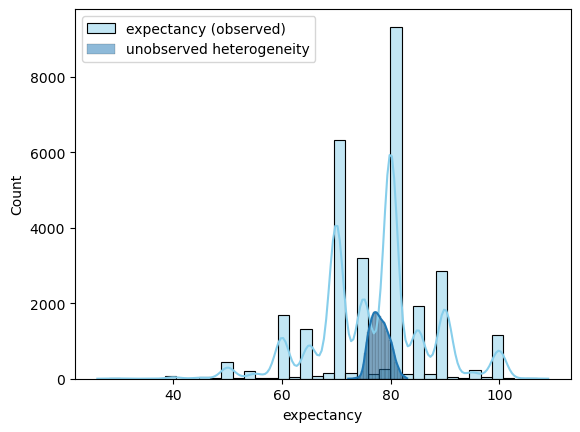

In [39]:
Xpred = X_cre.copy()
Xpred['edu'] = 0
Xpred['children'] = 0
Xpred['exp'] = 0
Xpred['wage'] = 0
Xpred['cotizando'] = 0
Xpred['publicemp'] = 0
Xpred['sistema'] = 0
Xpred['assets'] = 0
Xpred['exp_sist'] = 0
Xpred['cronica'] = 0
Xpred['nocronica'] = 0
Xpred['mental'] = 0
Xpred['status_2.0'] = 0
Xpred['status_3.0'] = 0
Xpred['status_4.0'] = 0
Xpred['status_5.0'] = 0
Xpred['situation_3'] = 0
Xpred['situation_4'] = 0
Xpred['occupation_1.0'] = 0

yhat = cre.predict(Xpred)

sns.histplot(data=y, color="skyblue", label="expectancy (observed)", kde=True, bins=40)
sns.histplot(data=yhat, color="red", label="unobserved heterogeneity", kde=True, bins=40)

plt.legend()
plt.show()


La forma del gráfico se puede explicar al la mayoria de personas haber respondido una expectativa de vida multiplo de 5, es por esto que hay estos saltos. Por otro lado, la heterogeneidad no observada tiene una forma similar pero más suave que la distribución observada, lo cual sugiere que una parte importante de la variabilidad de la expectativa puede deberse a factores no observados.

Ambas parecen tener una distribución Normal.

El hecho de que la distribución de la heterogeneidad no observada se concentre principalmente entre los 70 y 80 años, mientras que la distribución observada de la expectativa de vida muestra una mayor dispersión, sugiere que el modelo CRE no logra capturar completamente toda la variabilidad presente en los datos observados.

Esta discrepancia indica que pueden existir factores no observables relevantes que aún no han sido completamente explicados por las variables incluidas en el modelo, sin embargo, el uso del modelo CRE es apropiado precisamente porque permite incorporar esta heterogeneidad no observada de forma sistemática, al introducir componentes individuales que están correlacionados con las variables explicativas, mejorando así la estimación frente a un modelo de efectos aleatorios estándar.

La heterogeneidad fija en el tiempo vemos que distribuye normal, y anteriormente notamos que la mayoria de sus coeficientes fueron significativos, osea, impactan en la expectativa de vida.

### Parte 8

Como pudimos ver en el gráfico, sí existe heterogeneidad no observada en la expectativa de vida, ya que la distribución de este componente no explicado por las variables observadas se concentra en un rango diferente al de la distribución total observada. Esto sugiere que existen características individuales no incluidas en el modelo que afectan significativamente la expectativa de vida.

Por este motivo, es altamente conveniente utilizar CRE por sobre los otros modelos, ya que este permite capturar la correlación entre los efectos no observados y las variables explicativas.

Además, este modelo tiene supuestos más flexibles que los efectos aleatorios puros, y permite una comparación más coherente con los efectos fijos, ya que su formulación incorpora ambos modelos.